# Oil Spread Strategy — Geopolitical Event Analysis

How does the mean reversion strategy behave during major geopolitical shocks?
This workbook isolates each event, examines how spreads moved, what signals fired,
and whether the strategy made or lost money during the disruption.

---

## Events Analysed

| # | Event | Period | Key Dynamic |
|---|---|---|---|
| 1 | Abqaiq Drone Attack | Sep–Oct 2019 | Saudi infrastructure hit; Brent premium spiked |
| 2 | Soleimani Assassination (US–Iran) | Jan 2020 | Short-lived geopolitical risk premium in WTI/Brent |
| 3 | COVID Crash + Saudi–Russia Price War | Feb–Jul 2020 | WTI briefly negative; crack spreads inverted |
| 4 | Russia–Ukraine Invasion | Feb–Jul 2022 | Energy crisis; crack spreads blew to historic highs |
| 5 | Iran–Israel Direct Strike | Apr–May 2024 | First direct state-on-state Iran attack; Brent premium |
| 6 | US–Iran War | Mar–Apr 2026 | Strait of Hormuz risk; crude and product spread dislocation |


## Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath(".")))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

from config   import INITIAL_CAPITAL, DEFAULT_Z_EXIT
from data     import fetch_all
from spreads  import build_all_spreads
from signals  import compute_signals
from backtest import run_backtest
from metrics  import portfolio_stats, per_spread_stats, sharpe_float

# ── Plot theme ────────────────────────────────────────────────────────────────
DARK  = "#0d1117"; PANEL = "#161b22"; GRID = "#21262d"
TEXT  = "#c9d1d9"; GREEN = "#3fb950"; RED  = "#f85149"
BLUE  = "#58a6ff"; GOLD  = "#d29922"; PURPLE = "#bc8cff"
ORANGE = "#ff7b72"

plt.rcParams.update({
    "figure.facecolor": DARK, "axes.facecolor": PANEL,
    "axes.edgecolor": GRID, "axes.labelcolor": TEXT,
    "xtick.color": TEXT, "ytick.color": TEXT,
    "text.color": TEXT, "grid.color": GRID,
    "grid.linewidth": 0.4, "axes.grid": True,
})

print("Setup complete.")


Setup complete.


## Data & Strategy Run

Fetching data from 2015 through today to capture all events including US–Iran 2026.


In [2]:
# Extend to today to capture the 2026 US-Iran event
START = "2015-01-01"
END   = pd.Timestamp.today().strftime("%Y-%m-%d")

print(f"Fetching {START} → {END}...")
prices = fetch_all(START, END)

spreads_df = build_all_spreads(prices)
signals    = compute_signals(spreads_df)
result     = run_backtest(signals, INITIAL_CAPITAL)

equity = result["equity"]
trades = result["trades"]

print(f"\nData loaded: {len(list(prices.values())[0]):,} bars")
print(f"Trades:      {len(trades)}")
print(f"Equity:      ${equity.iloc[0]/1e6:.1f}M → ${equity.iloc[-1]/1e6:.1f}M")


Fetching 2015-01-01 → 2026-04-22...
  CL (CL=F): 2,841 bars
  BZ (BZ=F): 2,842 bars
  HO (HO=F): 2,842 bars
  RB (RB=F): 2,842 bars

Data loaded: 2,841 bars
Trades:      1154
Equity:      $10.0M → $58.4M


In [3]:
EVENTS = {
    "Abqaiq Attack\n(Sep 2019)": {
        "start": "2019-09-13", "end": "2019-10-18",
        "color": PURPLE,
        "description": (
            "Drone and missile strikes on Saudi Aramco's Abqaiq processing facility "
            "and Khurais oil field knocked out ~5% of global supply overnight. "
            "Brent spiked 15% on open — the largest single-day move in decades. "
            "WTI–Brent spread widened as Middle Eastern supply risk premium surged."
        ),
    },
    "Soleimani Killing\n(Jan 2020)": {
        "start": "2020-01-03", "end": "2020-01-24",
        "color": ORANGE,
        "description": (
            "US drone strike killed IRGC Quds Force commander Qasem Soleimani near Baghdad airport. "
            "Immediate WTI/Brent spike on Strait of Hormuz closure fears. "
            "Risk premium faded within two weeks as Iran's retaliation was limited. "
            "Short-lived but violent — tests whether the strategy chases or fades the move."
        ),
    },
    "COVID + Saudi-Russia\nPrice War (2020)": {
        "start": "2020-02-01", "end": "2020-07-15",
        "color": RED,
        "description": (
            "Demand destruction from global lockdowns combined with Saudi Arabia flooding "
            "markets after OPEC+ talks collapsed. WTI May futures settled at -$37.63/bbl "
            "(Apr 20, 2020) — physically impossible to store barrels. "
            "Crack spreads inverted as refiners cut runs. The ultimate mean reversion stress test."
        ),
    },
    "Russia-Ukraine\nInvasion (2022)": {
        "start": "2022-02-24", "end": "2022-07-01",
        "color": GOLD,
        "description": (
            "Russia invaded Ukraine on Feb 24 2022. Brent surged past $130/bbl. "
            "European energy crisis: heating oil (diesel proxy) crack spreads hit "
            "record highs as the continent scrambled to replace Russian supply. "
            "Highest volatility environment for oil spreads in the dataset."
        ),
    },
    "Iran-Israel\nDirect Strike (Apr 2024)": {
        "start": "2024-04-13", "end": "2024-05-15",
        "color": BLUE,
        "description": (
            "Iran launched 300+ drones and missiles directly at Israel on Apr 13 2024 "
            "— the first direct state-on-state attack in the conflict's history. "
            "Brent briefly spiked on Hormuz closure fears; WTI–Brent spread widened. "
            "Markets stabilised rapidly as the attack was largely intercepted."
        ),
    },
    "US-Iran War\n(Mar 2026)": {
        "start": "2026-03-01", "end": pd.Timestamp.today().strftime("%Y-%m-%d"),
        "color": GREEN,
        "description": (
            "Escalating US-Iran military confrontation in March 2026, including strikes "
            "on Iranian nuclear and military sites and Iranian counter-strikes on Gulf "
            "energy infrastructure. Strait of Hormuz closure risk drove Brent and WTI "
            "sharply higher. Crack spreads dislocated as regional refinery throughput fell."
        ),
    },
}

print(f"{len(EVENTS)} events defined:")
for name, ev in EVENTS.items():
    print(f"  {name.replace("\n", ' '):40s}  {ev['start']} → {ev['end']}")


6 events defined:
  Abqaiq Attack (Sep 2019)                  2019-09-13 → 2019-10-18
  Soleimani Killing (Jan 2020)              2020-01-03 → 2020-01-24
  COVID + Saudi-Russia Price War (2020)     2020-02-01 → 2020-07-15
  Russia-Ukraine Invasion (2022)            2022-02-24 → 2022-07-01
  Iran-Israel Direct Strike (Apr 2024)      2024-04-13 → 2024-05-15
  US-Iran War (Mar 2026)                    2026-03-01 → 2026-04-22


In [4]:
def event_equity_stats(eq, trades, start, end):
    eq_w = eq.loc[start:end]
    if len(eq_w) < 2:
        return {}
    ret = eq_w.iloc[-1] / eq_w.iloc[0] - 1
    dd  = ((eq_w - eq_w.cummax()) / eq_w.cummax()).min()
    pnl_trades = [
        t for t in trades
        if pd.Timestamp(start) <= t.entry_date <= pd.Timestamp(end)
    ]
    pnls = [t.pnl_net for t in pnl_trades]
    wins = [p for p in pnls if p > 0]
    return {
        "return":     f"{ret:+.2%}",
        "max_dd":     f"{dd:.2%}",
        "n_trades":   len(pnl_trades),
        "total_pnl":  f"${sum(pnls):+,.0f}",
        "win_rate":   f"{len(wins)/len(pnls):.0%}" if pnls else "n/a",
        "sharpe":     f"{sharpe_float(eq_w):.2f}",
    }


def event_spread_returns(spreads_df, start, end):
    sw = spreads_df.loc[start:end]
    if sw.empty:
        return pd.Series(dtype=float)
    return ((sw.iloc[-1] - sw.iloc[0]) / sw.iloc[0].abs().replace(0, np.nan)).rename("chg")


def event_trades(trades, start, end):
    return [t for t in trades
            if pd.Timestamp(start) <= t.entry_date <= pd.Timestamp(end)]

print("Helper functions defined.")


Helper functions defined.


## Summary: Strategy Performance Across All Events

Before diving into each event individually, here's the at-a-glance comparison.


In [5]:
rows = []
for name, ev in EVENTS.items():
    stats = event_equity_stats(equity, trades, ev["start"], ev["end"])
    if not stats:
        continue
    rows.append({
        "Event":     name.replace("\n", " "),
        "Period":    f"{ev['start']} → {ev['end']}",
        "Return":    stats["return"],
        "Max DD":    stats["max_dd"],
        "Trades":    stats["n_trades"],
        "Total PnL": stats["total_pnl"],
        "Win Rate":  stats["win_rate"],
        "Sharpe":    stats["sharpe"],
    })

summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))


                                Event                  Period  Return Max DD  Trades   Total PnL Win Rate Sharpe
             Abqaiq Attack (Sep 2019) 2019-09-13 → 2019-10-18  +1.29% -0.38%       9   $+869,057      78%   1.95
         Soleimani Killing (Jan 2020) 2020-01-03 → 2020-01-24  -3.78% -3.78%      10   $-414,433      10% -10.22
COVID + Saudi-Russia Price War (2020) 2020-02-01 → 2020-07-15 +12.84% -2.51%      39 $+3,096,615      49%   1.56
       Russia-Ukraine Invasion (2022) 2022-02-24 → 2022-07-01  -3.17% -7.91%      30   $-761,673      33%  -1.59
 Iran-Israel Direct Strike (Apr 2024) 2024-04-13 → 2024-05-15  -2.10% -2.10%       7 $-1,270,909       0%  -5.78
               US-Iran War (Mar 2026) 2026-03-01 → 2026-04-22  -1.04% -2.50%      12   $-314,898      42%  -2.10


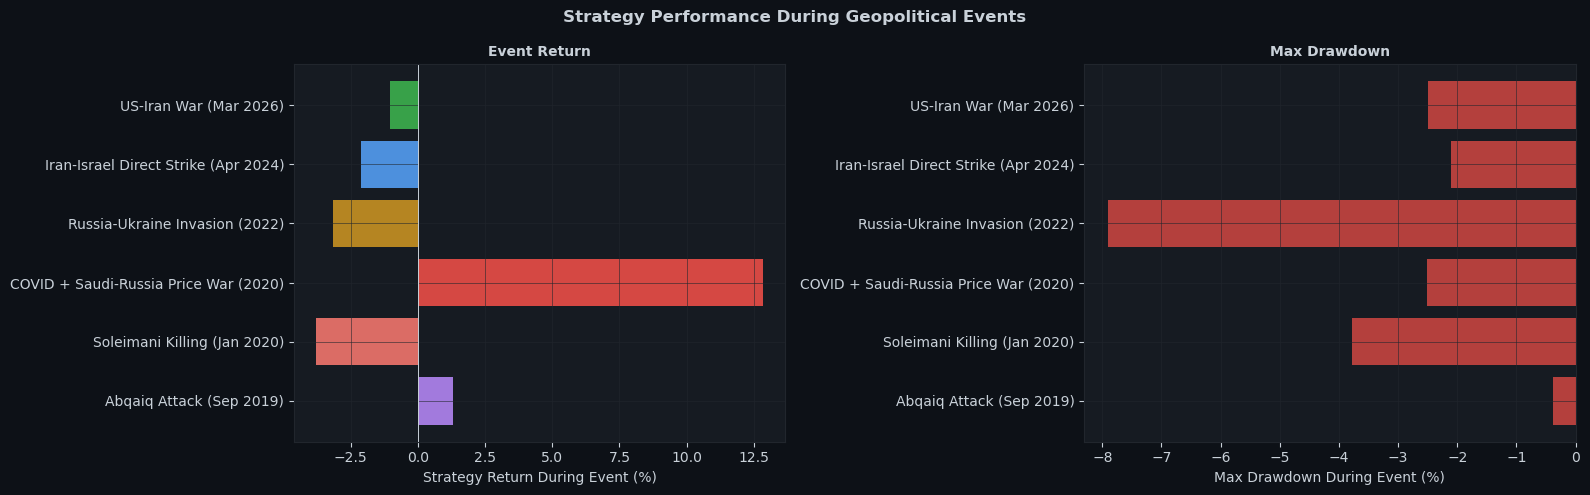

In [6]:
# Visual summary — returns and drawdowns per event
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5), facecolor=DARK)
fig.suptitle("Strategy Performance During Geopolitical Events", color=TEXT,
             fontsize=12, fontweight="bold")

names  = [r["Event"] for r in rows]
rets   = [float(r["Return"].replace("%","").replace("+",""))/100 for r in rows]
dds    = [float(r["Max DD"].replace("%",""))/100 for r in rows]
colors = [list(EVENTS.values())[i]["color"] for i in range(len(rows))]

ax1.barh(names, [r*100 for r in rets], color=colors, alpha=0.85)
ax1.axvline(0, color=TEXT, lw=0.7)
ax1.set_xlabel("Strategy Return During Event (%)")
ax1.set_title("Event Return", color=TEXT, fontsize=10, fontweight="bold")
ax1.grid(True, color=GRID, lw=0.4, axis="x")

ax2.barh(names, [d*100 for d in dds], color=RED, alpha=0.7)
ax2.set_xlabel("Max Drawdown During Event (%)")
ax2.set_title("Max Drawdown", color=TEXT, fontsize=10, fontweight="bold")
ax2.grid(True, color=GRID, lw=0.4, axis="x")

plt.tight_layout()
plt.show()


## Individual Event Deep Dives

In [7]:
def plot_event(event_name, ev, prices, spreads_df, signals, equity, trades):
    s, e = ev["start"], ev["end"]
    color = ev["color"]

    # Slice data
    px_w  = {k: v.loc[s:e] for k, v in prices.items()}
    sp_w  = spreads_df.loc[s:e]
    eq_w  = equity.loc[s:e]
    ev_tr = event_trades(trades, s, e)

    # Normalise prices to 100 at start
    px_norm = pd.DataFrame({k: v / v.iloc[0] * 100 for k, v in px_w.items() if len(v) > 0})

    # Key spreads to highlight
    key_spreads = ["wti_brent", "crack_321", "crack_rb", "fly_rb_cl_ho"]
    key_spreads = [c for c in key_spreads if c in sp_w.columns]

    fig = plt.figure(figsize=(18, 16), facecolor=DARK)
    fig.suptitle(f"{event_name.replace("\n", ' ')}  |  {s} → {e}",
                 color=color, fontsize=13, fontweight="bold")

    gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.35,
                           top=0.91, bottom=0.05, left=0.06, right=0.97)

    def _style(ax, title=""):
        ax.set_facecolor(PANEL)
        ax.tick_params(colors=TEXT, labelsize=7)
        for sp in ax.spines.values():
            sp.set_color(GRID)
        ax.xaxis.label.set_color(TEXT)
        ax.yaxis.label.set_color(TEXT)
        if title:
            ax.set_title(title, color=TEXT, fontsize=9, pad=4, fontweight="bold")
        ax.grid(True, color=GRID, lw=0.4)

    # 1. Normalised prices
    ax1 = fig.add_subplot(gs[0, :2])
    c_map = {"CL": GOLD, "BZ": BLUE, "HO": ORANGE, "RB": GREEN}
    for k, ser in px_norm.items():
        ax1.plot(ser.index, ser, color=c_map.get(k, TEXT), lw=1.1, label=k)
    ax1.axhline(100, color=TEXT, ls="--", lw=0.5, alpha=0.4)
    ax1.set_ylabel("Indexed (100 = event start)")
    ax1.legend(fontsize=8, facecolor=PANEL, labelcolor=TEXT, ncol=4)
    _style(ax1, "Price Performance (Indexed to 100)")

    # 2. Strategy equity
    ax2 = fig.add_subplot(gs[0, 2])
    if len(eq_w) > 1:
        eq_idx = eq_w / eq_w.iloc[0] * 100
        ax2.plot(eq_idx.index, eq_idx, color=color, lw=1.2)
        ax2.axhline(100, color=TEXT, ls="--", lw=0.5, alpha=0.4)
        ax2.set_ylabel("Strategy Equity (indexed)")
        stats = event_equity_stats(equity, trades, s, e)
        ax2.set_title(
            f"Strategy Equity\nRet: {stats['return']}  Sharpe: {stats['sharpe']}",
            color=TEXT, fontsize=8, pad=4, fontweight="bold"
        )
        ax2.grid(True, color=GRID, lw=0.4)
        ax2.set_facecolor(PANEL)
        ax2.tick_params(colors=TEXT, labelsize=7)
        for sp in ax2.spines.values():
            sp.set_color(GRID)

    # 3–6. Key spread panels with z-score overlay
    for idx, spread_name in enumerate(key_spreads[:4]):
        row = 1 + idx // 3
        col = idx % 3
        ax = fig.add_subplot(gs[row, col])
        ss = signals[spread_name]
        sp_ser  = ss.spread.loc[s:e]
        z_ser   = ss.zscore.loc[s:e]
        sig_ser = ss.signal.loc[s:e]

        if sp_ser.empty:
            ax.set_visible(False)
            continue

        ax2b = ax.twinx()
        ax2b.plot(z_ser.index, z_ser, color=BLUE, lw=0.6, alpha=0.7)
        ax2b.axhline( ss.z_entry, color=GREEN, ls="--", lw=0.6, alpha=0.7)
        ax2b.axhline(-ss.z_entry, color=RED,   ls="--", lw=0.6, alpha=0.7)
        ax2b.axhline(0, color=TEXT, lw=0.3, alpha=0.3)
        ax2b.set_ylabel("Z", color=BLUE, fontsize=6)
        ax2b.tick_params(colors=BLUE, labelsize=6)
        ax2b.set_facecolor(PANEL)
        for sp in ax2b.spines.values():
            sp.set_color(GRID)

        ax.plot(sp_ser.index, sp_ser, color=GOLD, lw=0.9)
        ax.fill_between(sp_ser.index, sp_ser, sp_ser.mean(),
                        where=(sig_ser == 1),  color=GREEN, alpha=0.2)
        ax.fill_between(sp_ser.index, sp_ser, sp_ser.mean(),
                        where=(sig_ser == -1), color=RED, alpha=0.2)
        ax.set_ylabel("$/bbl", fontsize=7)
        _style(ax, spread_name.replace("_", " ").title())

    # 5. Trade log table
    ax_t = fig.add_subplot(gs[2, 2])
    ax_t.axis("off")
    if ev_tr:
        t_data = [[
            t.entry_date.strftime("%m/%d"),
            t.spread_name.replace("_"," ")[:14],
            "L" if t.direction==1 else "S",
            f"${t.pnl_net/1e3:+.1f}K",
            "OK" if not t.stopped_out else "STP",
        ] for t in sorted(ev_tr, key=lambda x: x.entry_date)]
        tbl = ax_t.table(
            cellText=t_data,
            colLabels=["Entry","Spread","Dir","PnL","Exit"],
            cellLoc="center", loc="center",
        )
        tbl.auto_set_font_size(False)
        tbl.set_fontsize(7)
        for (r, c), cell in tbl.get_celld().items():
            cell.set_facecolor(PANEL if r > 0 else GRID)
            cell.set_text_props(color=TEXT)
            cell.set_edgecolor(GRID)
        ax_t.set_title("Trades During Event", color=TEXT, fontsize=9,
                       pad=4, fontweight="bold")
    else:
        ax_t.text(0.5, 0.5, "No trades during\nthis event window",
                  ha="center", va="center", color=TEXT, fontsize=9,
                  transform=ax_t.transAxes)
        ax_t.set_title("Trades During Event", color=TEXT, fontsize=9, pad=4)

    # Description box
    fig.text(0.01, 0.01, ev["description"], color=TEXT, fontsize=7.5,
             va="bottom", wrap=True,
             bbox=dict(boxstyle="round,pad=0.4", facecolor=PANEL,
                       edgecolor=color, alpha=0.9),
             transform=fig.transFigure)

    plt.savefig(f"geo_{event_name.replace("\n",'_').replace(' ','_')}.png",
                dpi=130, bbox_inches="tight", facecolor=DARK)
    plt.show()

print("Plot function defined.")


Plot function defined.


### Abqaiq Attack (Sep 2019)

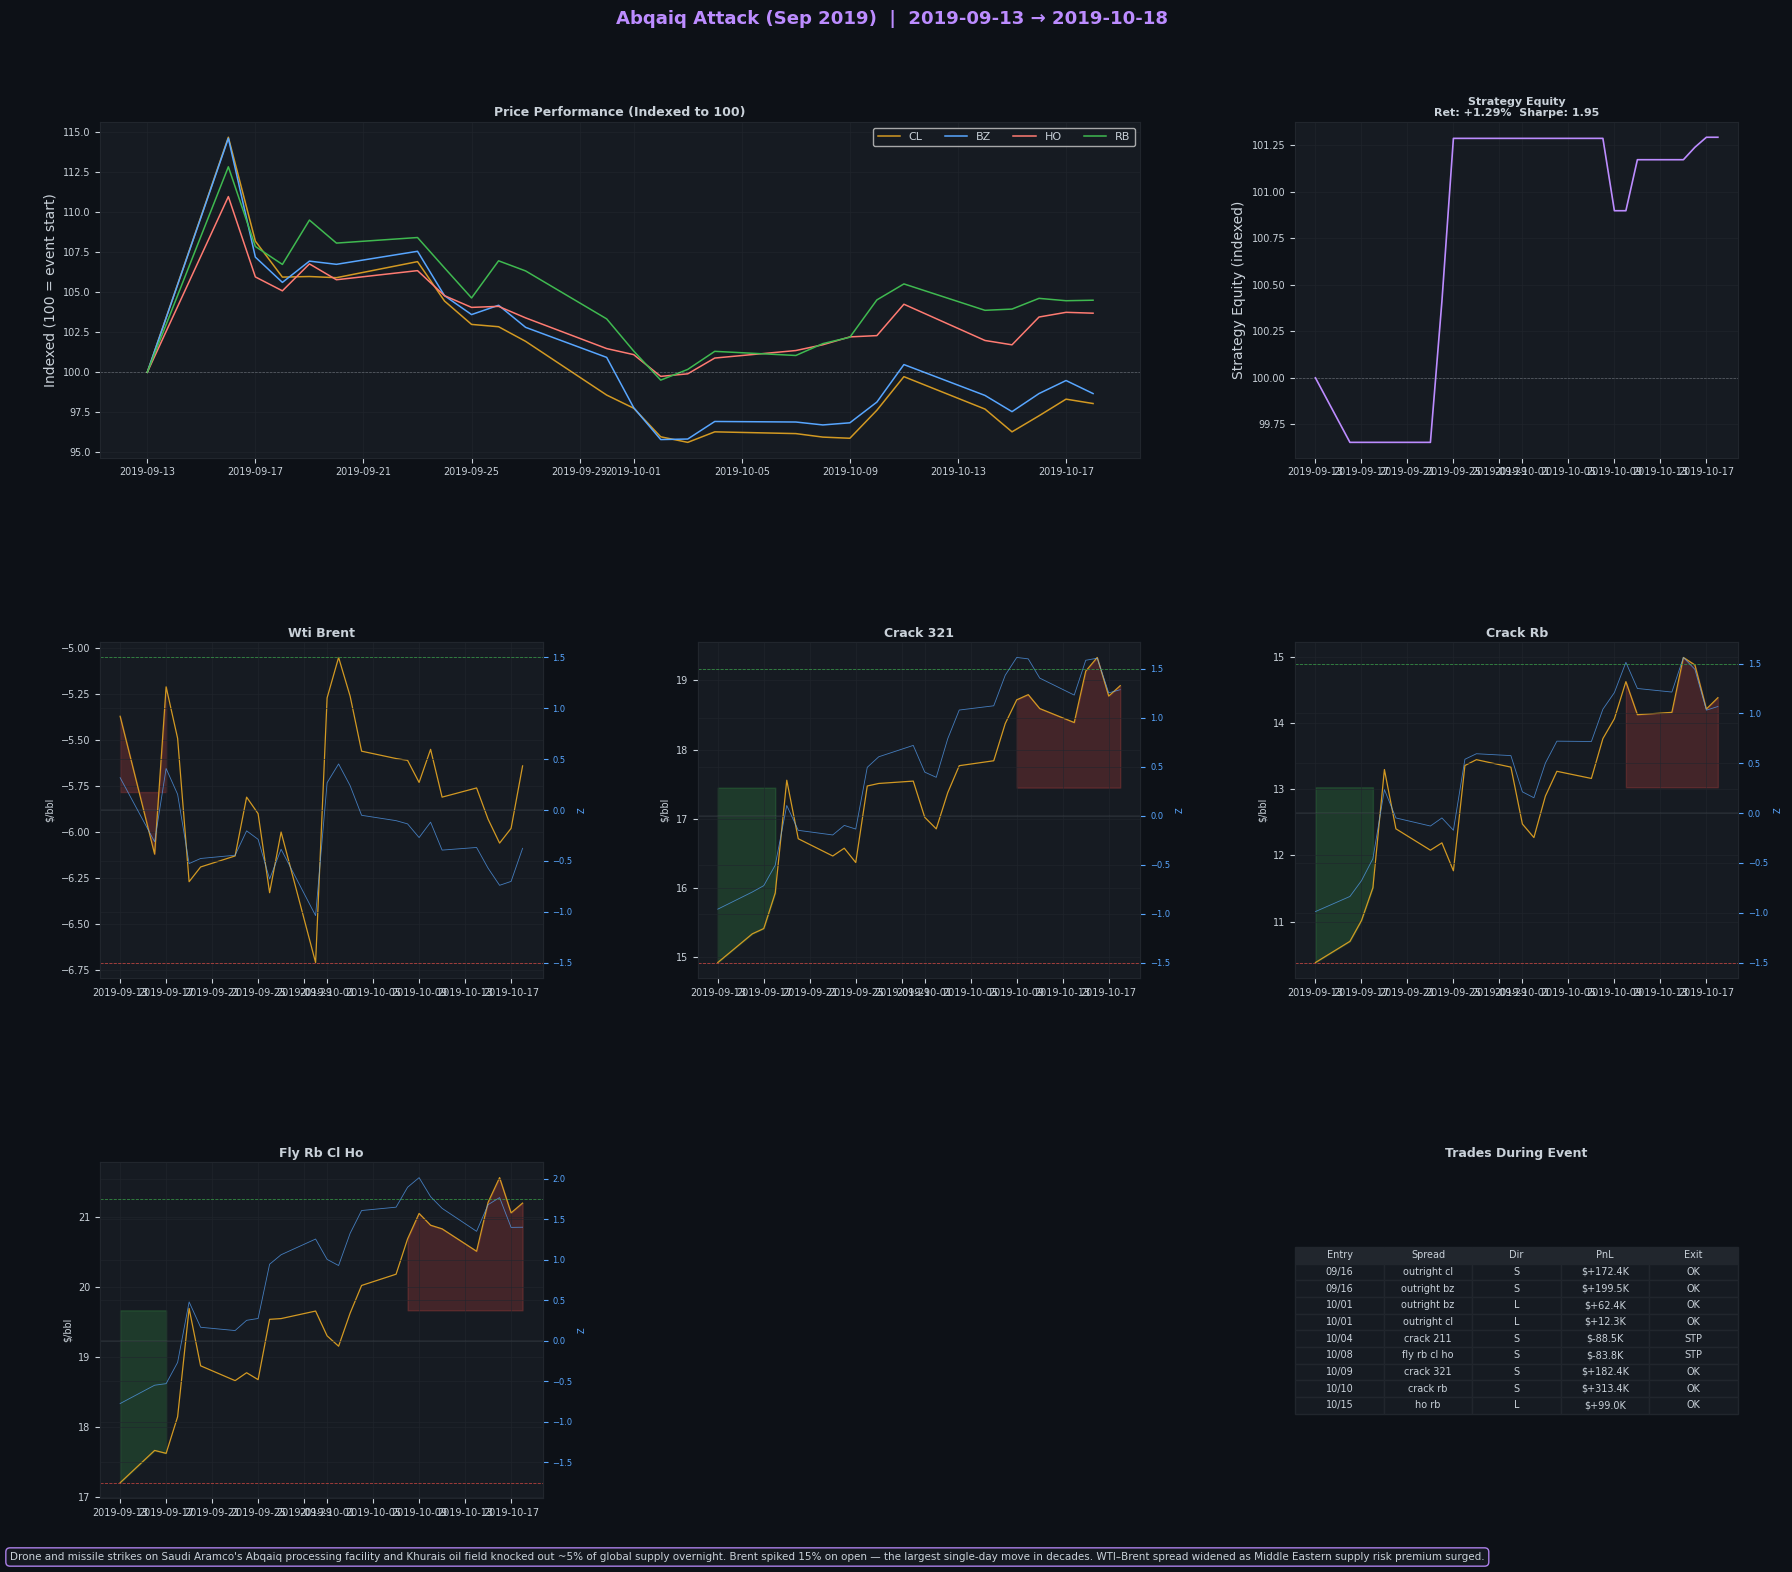

In [8]:
plot_event(
    "Abqaiq Attack\n(Sep 2019)",
    EVENTS["Abqaiq Attack\n(Sep 2019)"],
    prices, spreads_df, signals, equity, trades
)

### Soleimani Killing (Jan 2020)

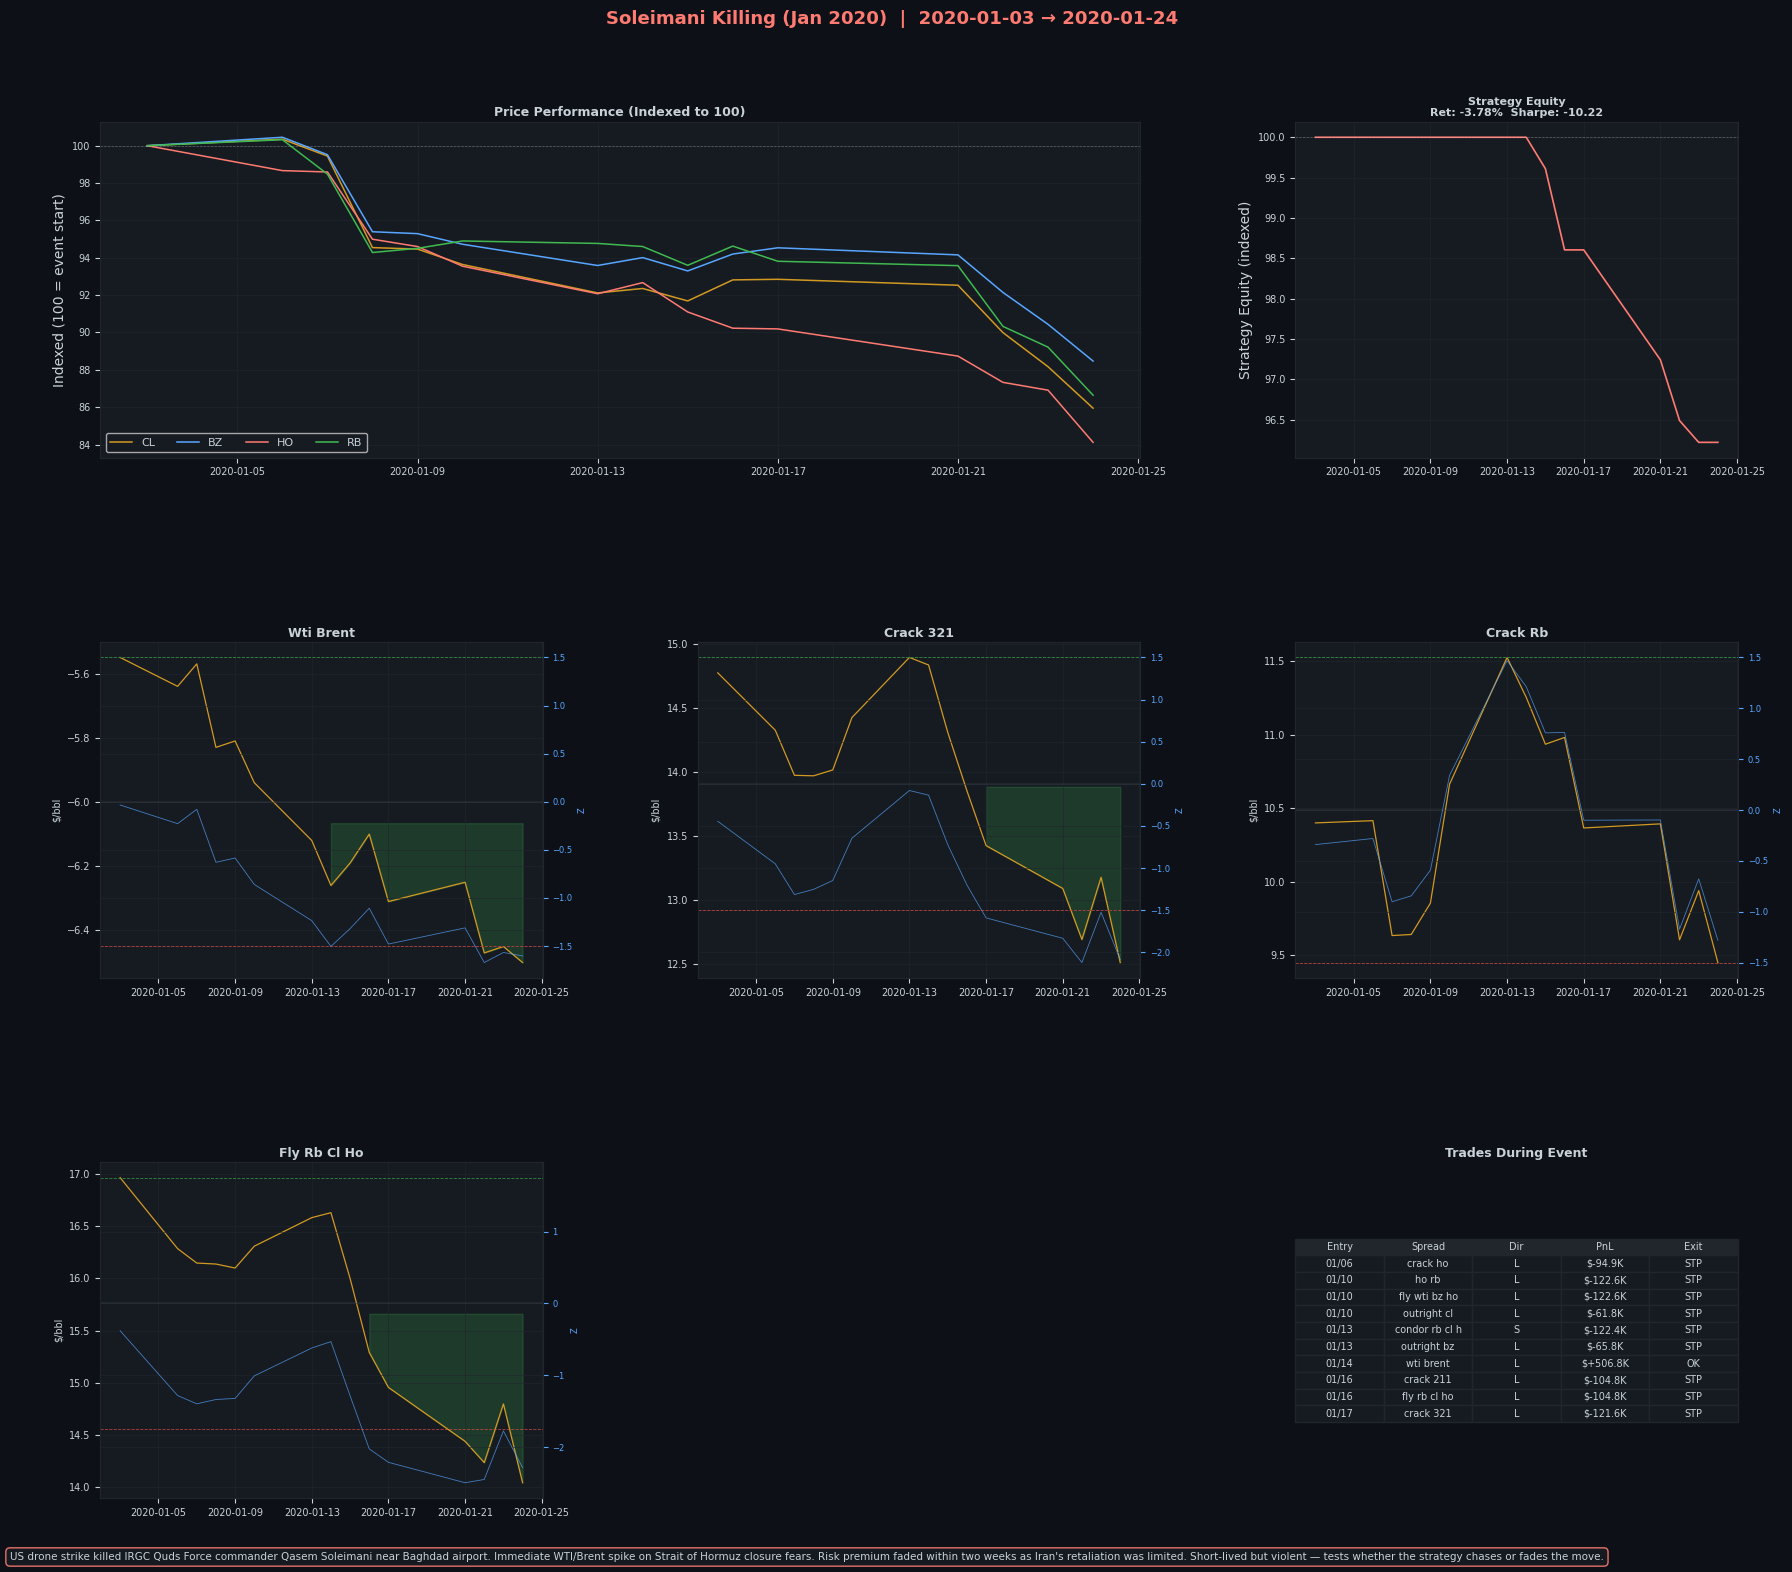

In [9]:
plot_event(
    "Soleimani Killing\n(Jan 2020)",
    EVENTS["Soleimani Killing\n(Jan 2020)"],
    prices, spreads_df, signals, equity, trades
)

### COVID + Saudi-Russia Price War (2020)

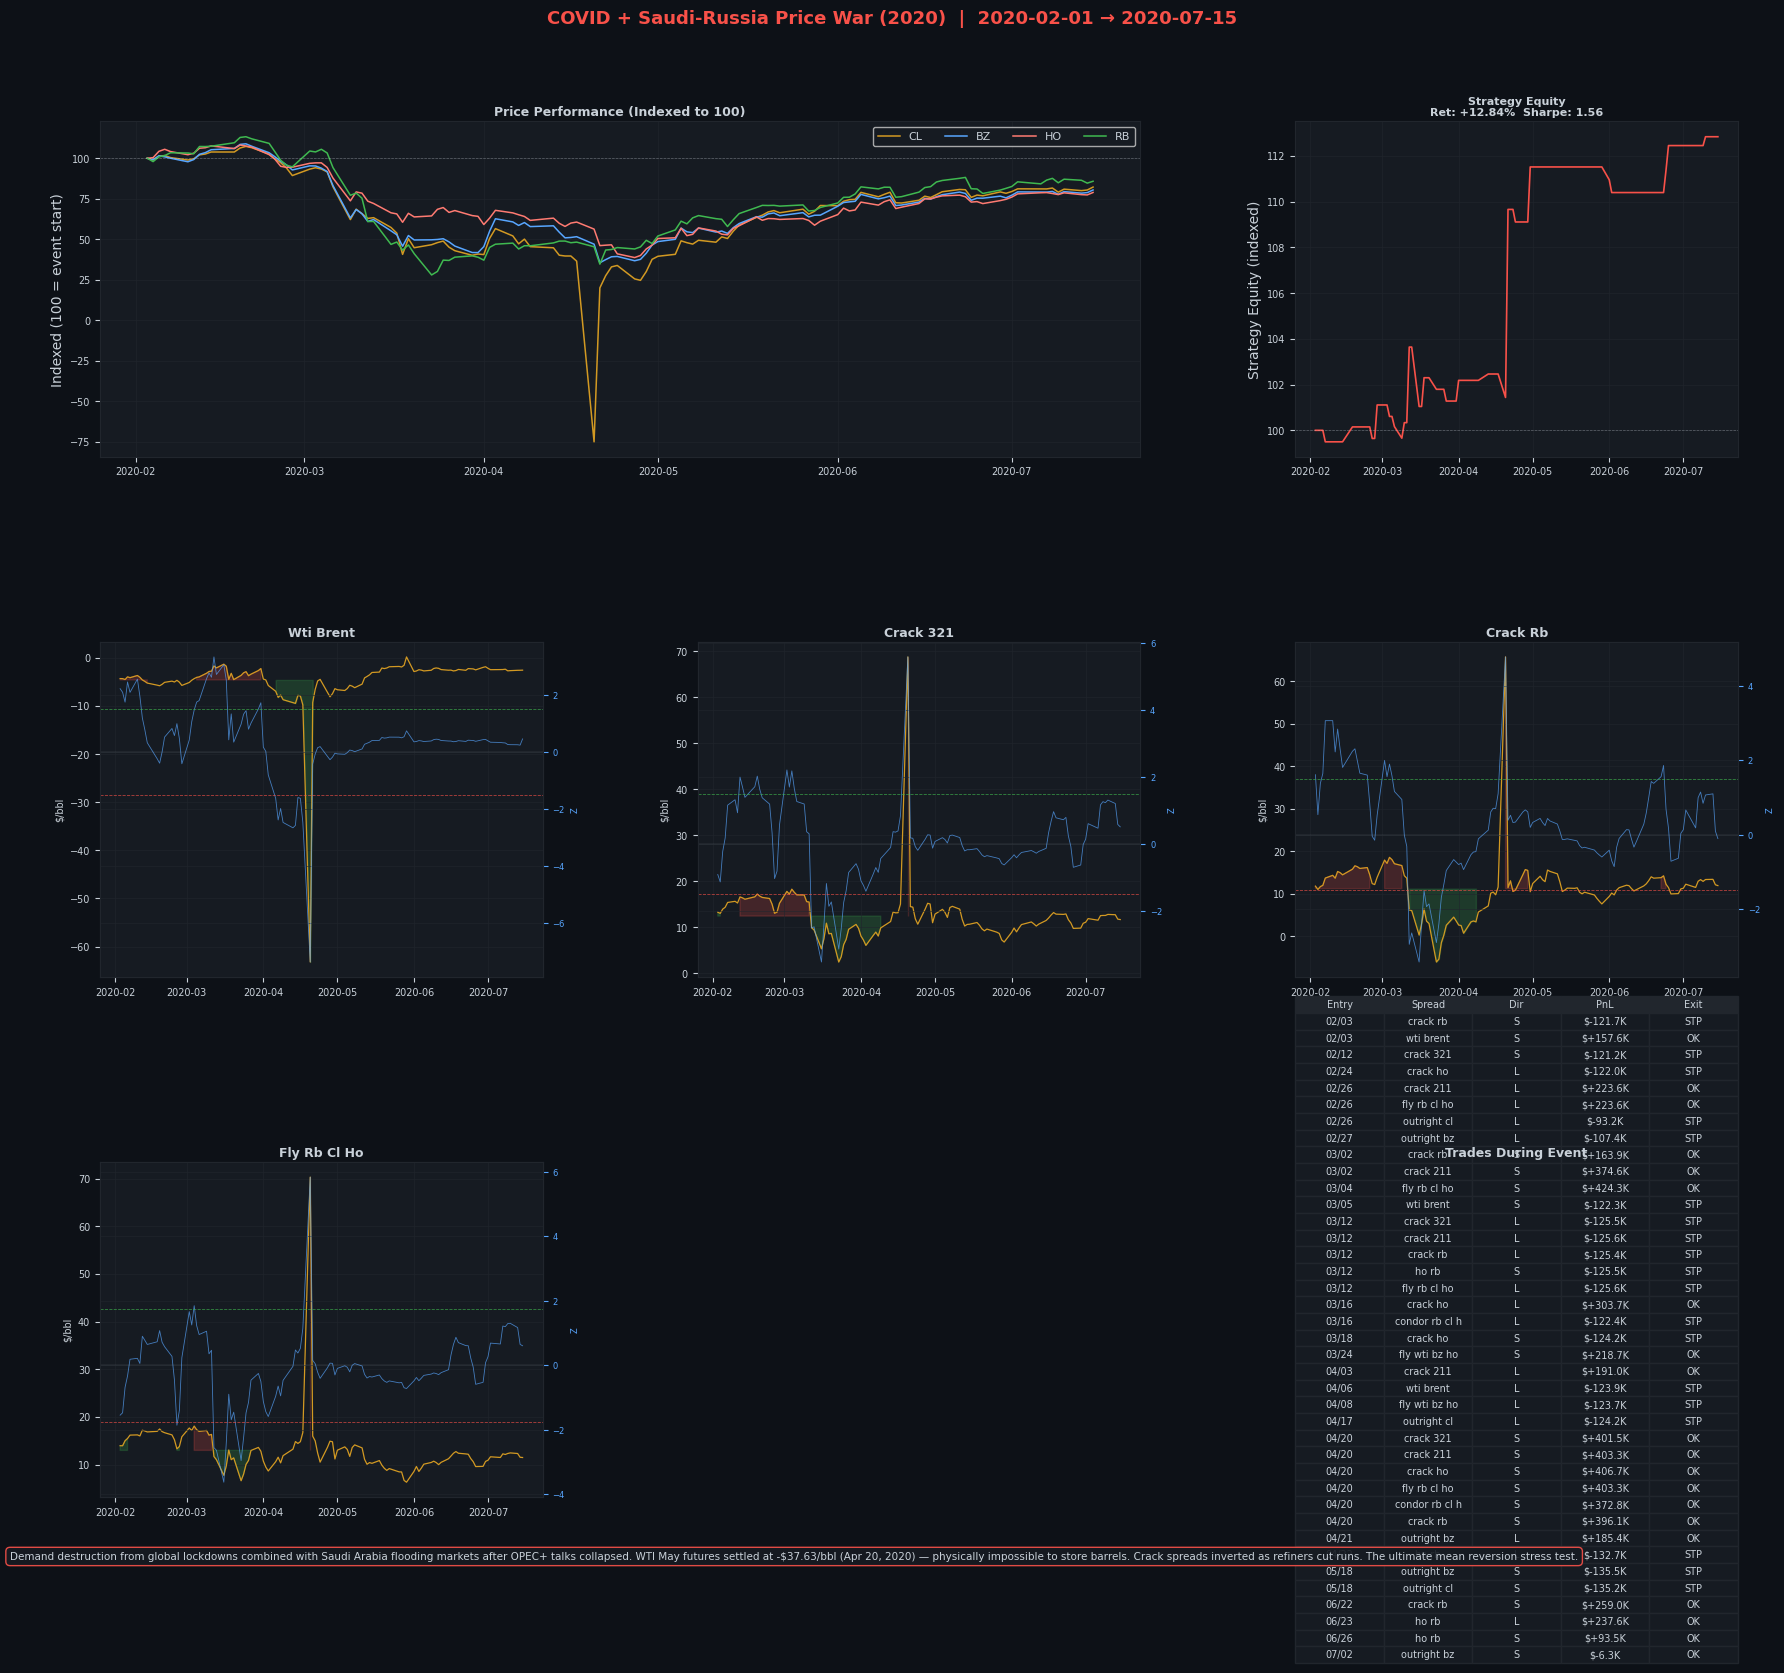

In [10]:
plot_event(
    "COVID + Saudi-Russia\nPrice War (2020)",
    EVENTS["COVID + Saudi-Russia\nPrice War (2020)"],
    prices, spreads_df, signals, equity, trades
)

### Russia-Ukraine Invasion (2022)

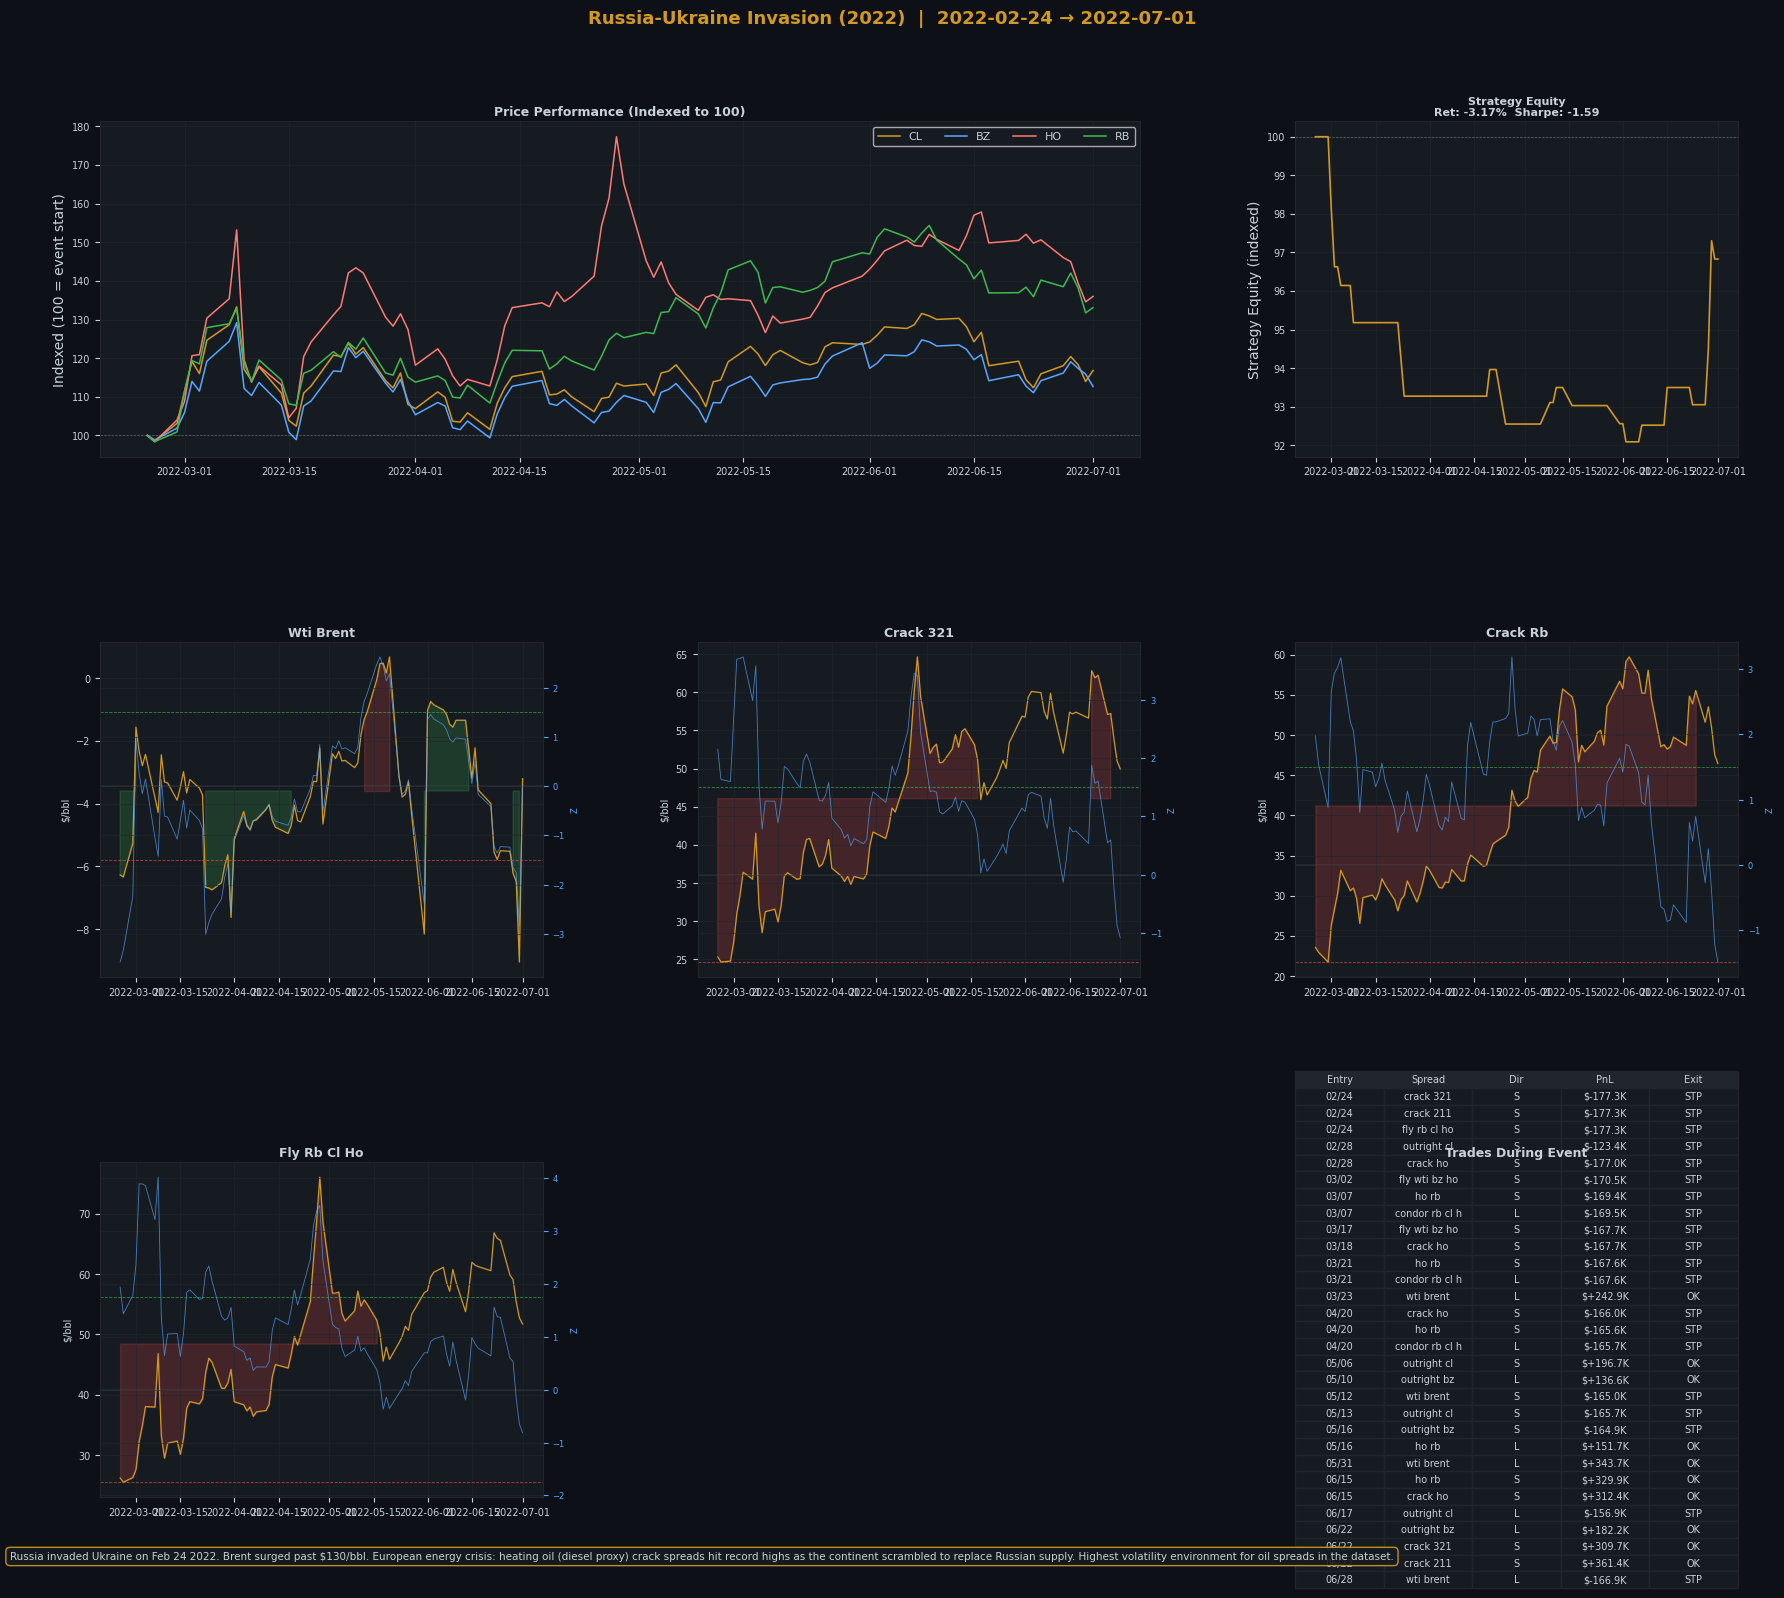

In [11]:
plot_event(
    "Russia-Ukraine\nInvasion (2022)",
    EVENTS["Russia-Ukraine\nInvasion (2022)"],
    prices, spreads_df, signals, equity, trades
)

### Iran-Israel Direct Strike (Apr 2024)

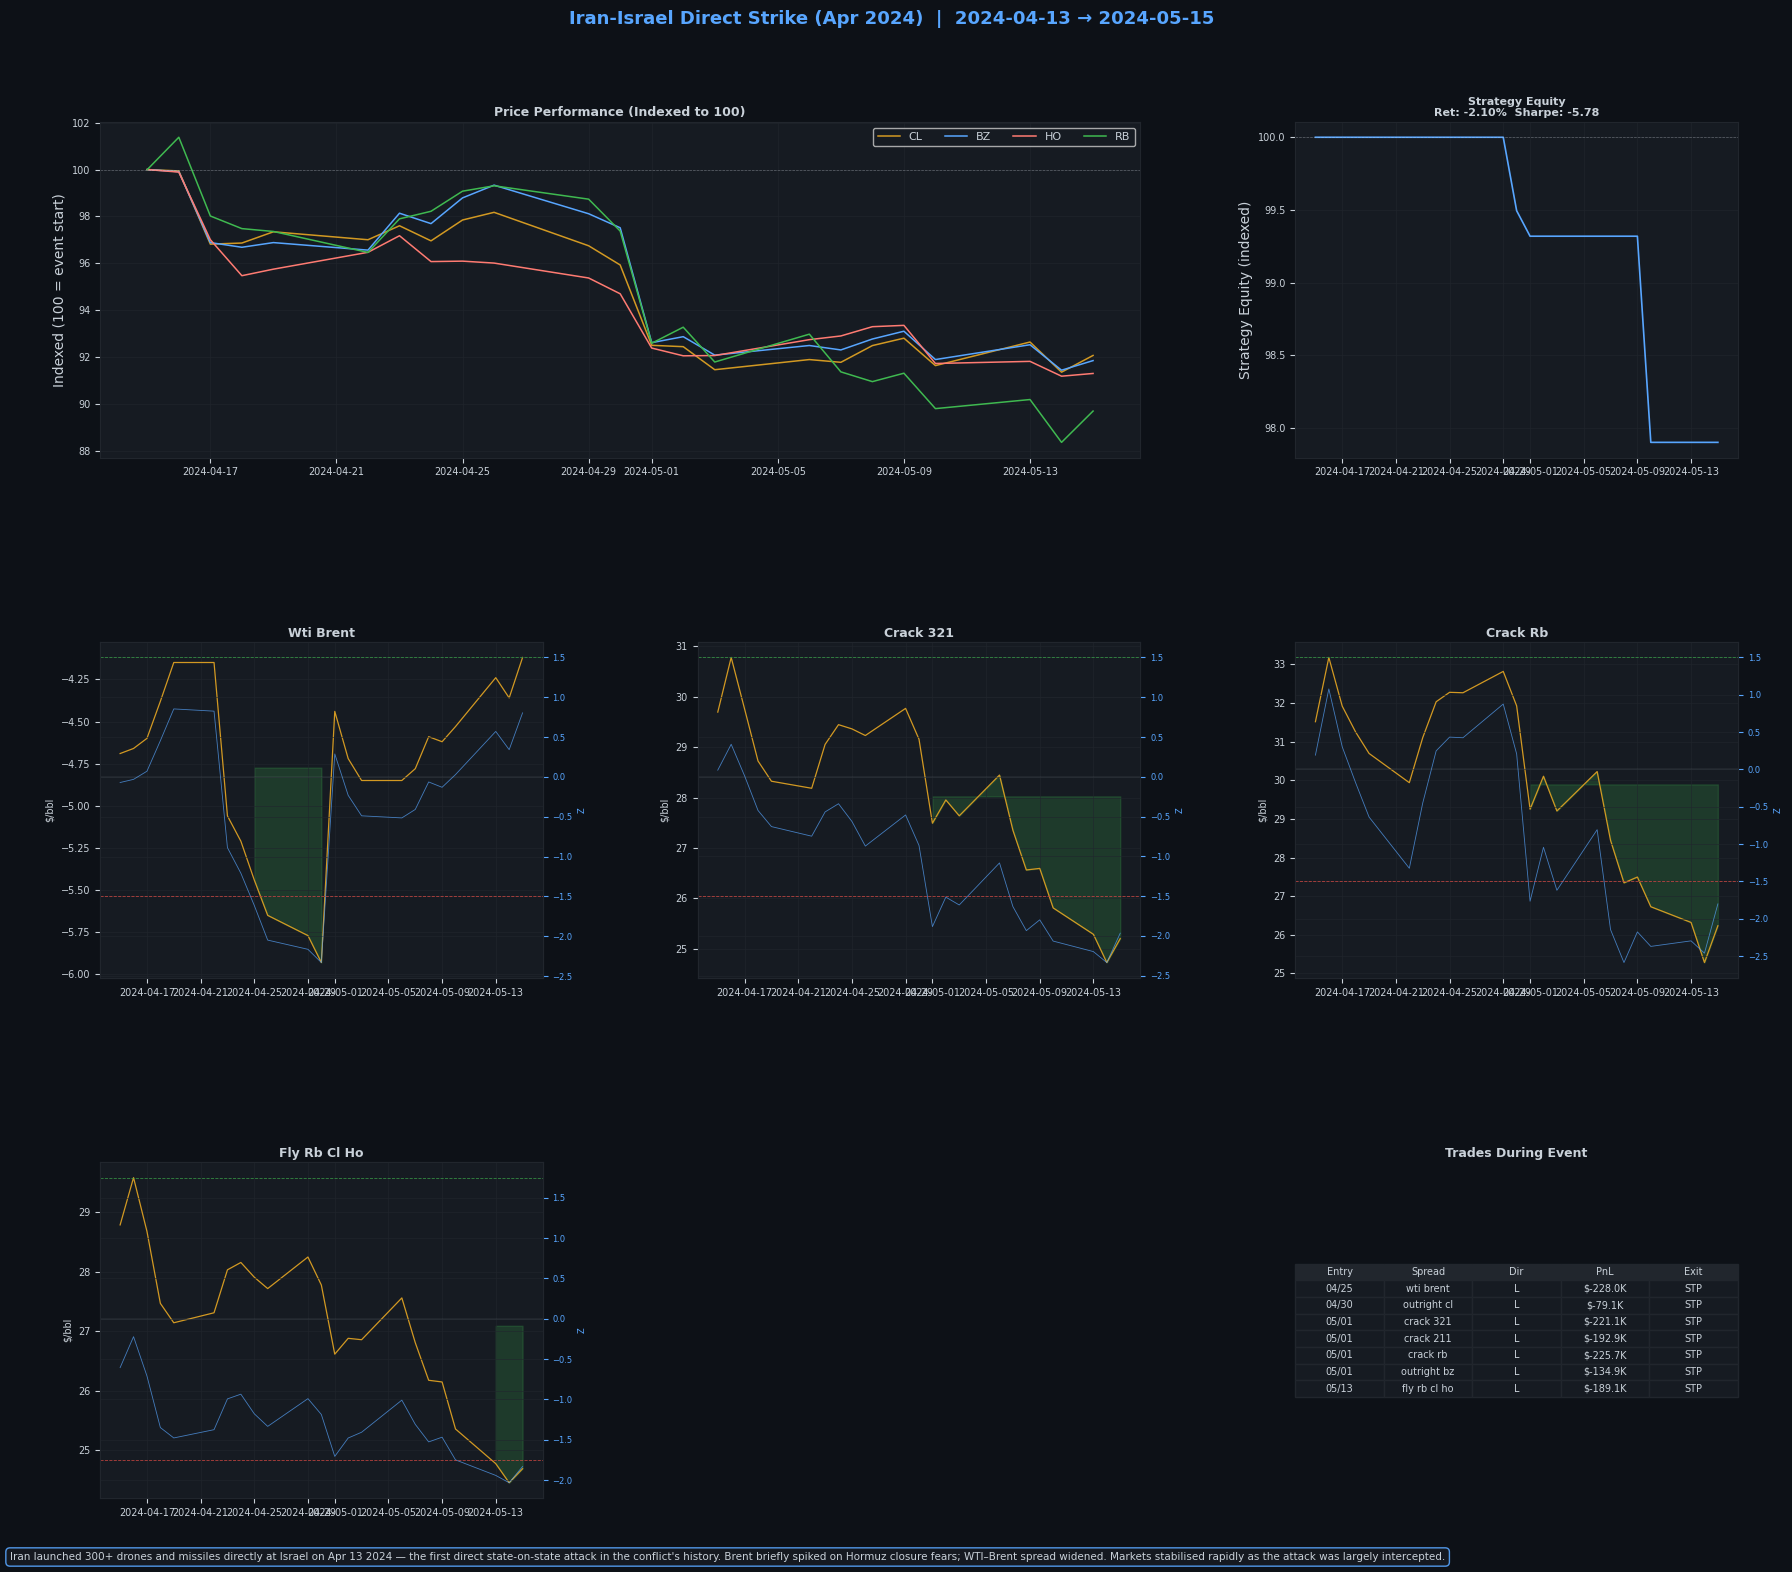

In [12]:
plot_event(
    "Iran-Israel\nDirect Strike (Apr 2024)",
    EVENTS["Iran-Israel\nDirect Strike (Apr 2024)"],
    prices, spreads_df, signals, equity, trades
)

### US-Iran War (Mar 2026)

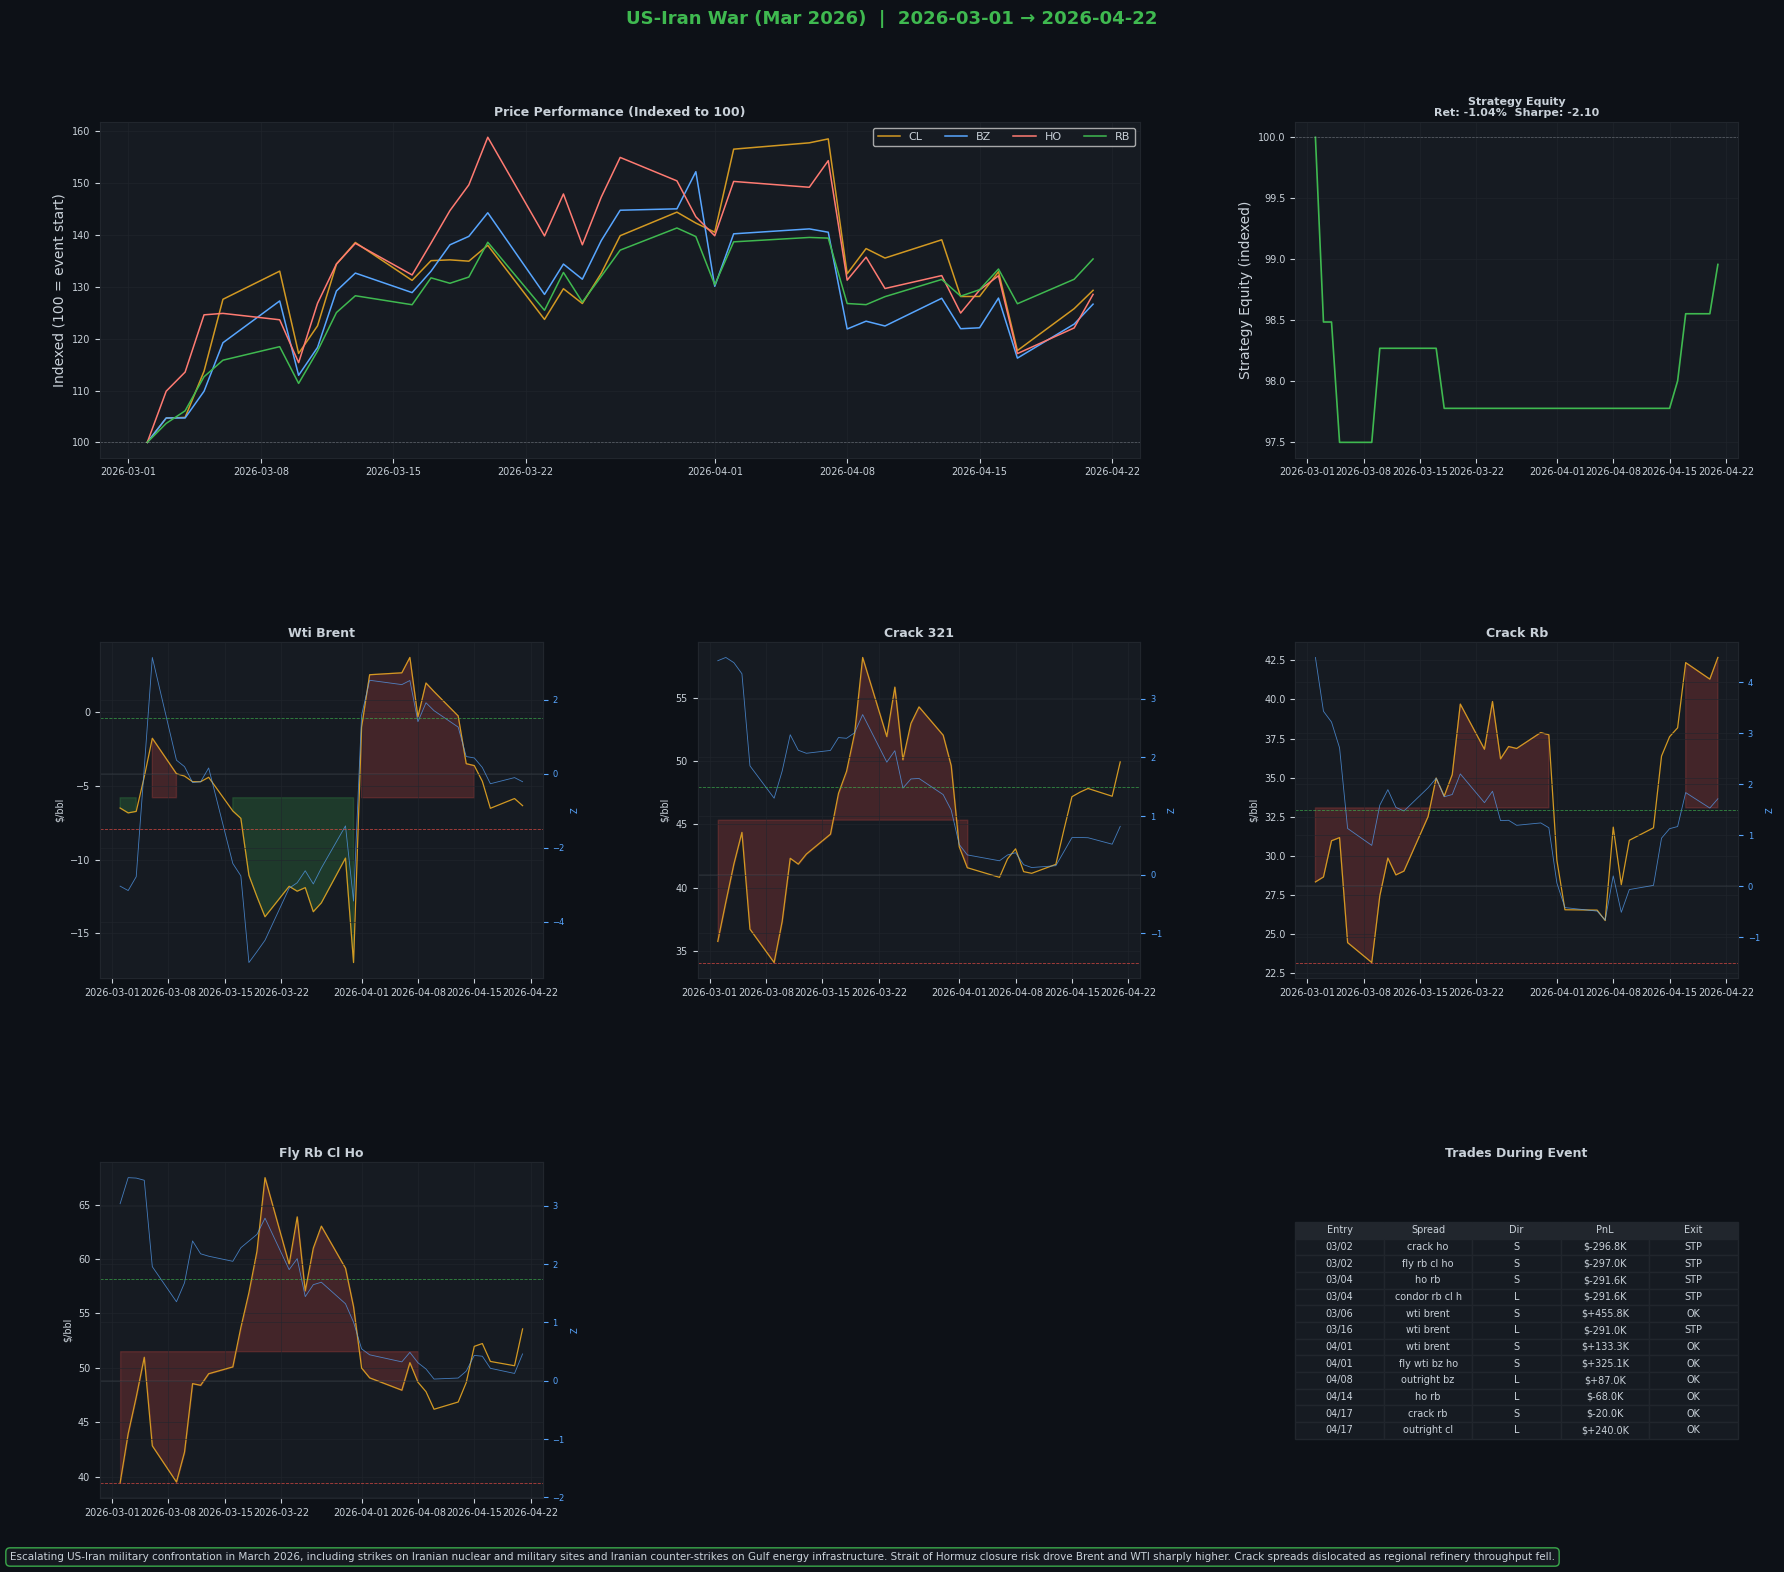

In [13]:
plot_event(
    "US-Iran War\n(Mar 2026)",
    EVENTS["US-Iran War\n(Mar 2026)"],
    prices, spreads_df, signals, equity, trades
)

## Spread Sensitivity by Event

Which spreads move the most during each event? This heatmap shows the percentage change
in each spread over the event window — useful for understanding which structures are
most exposed to each type of geopolitical shock.


In [14]:
# Build sensitivity matrix
sens_rows = {}
for name, ev in EVENTS.items():
    sp_w = spreads_df.loc[ev["start"]:ev["end"]]
    if sp_w.empty or len(sp_w) < 2:
        continue
    # % change from start to end
    chg = ((sp_w.iloc[-1] - sp_w.iloc[0]) / sp_w.iloc[0].abs().replace(0, np.nan)) * 100
    sens_rows[name.replace("\n", " ")] = chg

sens_df = pd.DataFrame(sens_rows).T
print("Spread % change during each event:")
print(sens_df.round(1).to_string())


Spread % change during each event:
                                       crack_321  crack_211  crack_ho  crack_rb  wti_brent  ho_rb  fly_wti_bz_ho  fly_rb_cl_ho  condor_rb_cl_ho_bz  outright_cl  outright_bz
Abqaiq Attack (Sep 2019)                    26.8       23.2      16.6      38.6       -5.0   -0.2           25.9          23.2                 3.6         -2.0         -1.3
Soleimani Killing (Jan 2020)               -15.3      -17.2     -20.8      -9.1      -17.1  -30.0          -54.6         -17.2                64.5        -14.1        -11.5
COVID + Saudi-Russia Price War (2020)      -12.2      -17.7     -31.4       1.0       40.3 -118.9          -21.1         -17.7              9488.4        -17.8        -19.6
Russia-Ukraine Invasion (2022)              97.3       97.3      97.5      97.1       49.0   99.4          210.1          97.3              -847.9         16.8         12.7
Iran-Israel Direct Strike (Apr 2024)       -15.1      -14.2     -11.2     -16.7       12.2   43.2   

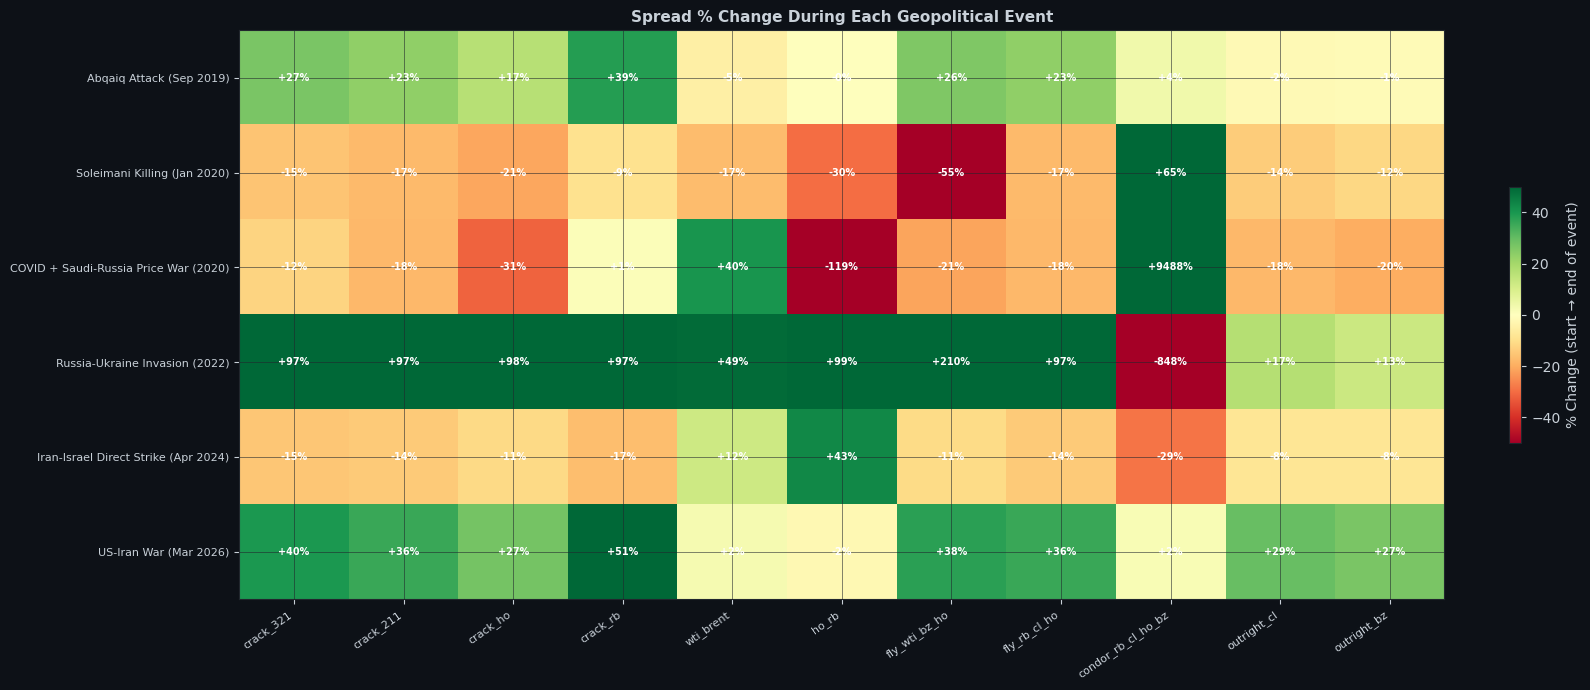

In [15]:
fig, ax = plt.subplots(figsize=(16, 7), facecolor=DARK)
im = ax.imshow(sens_df.values, cmap="RdYlGn", aspect="auto", vmin=-50, vmax=50)
ax.set_xticks(range(len(sens_df.columns)))
ax.set_xticklabels(sens_df.columns, rotation=35, ha="right", fontsize=8)
ax.set_yticks(range(len(sens_df.index)))
ax.set_yticklabels(sens_df.index, fontsize=8)
for r in range(len(sens_df.index)):
    for c in range(len(sens_df.columns)):
        v = sens_df.values[r, c]
        if not np.isnan(v):
            ax.text(c, r, f"{v:+.0f}%", ha="center", va="center",
                    color="white", fontsize=7, fontweight="bold")
plt.colorbar(im, ax=ax, fraction=0.01, label="% Change (start → end of event)")
ax.set_title("Spread % Change During Each Geopolitical Event",
             color=TEXT, fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()


## WTI–Brent Spread: Full History with Event Overlays

WTI–Brent is the most geopolitically sensitive spread in the universe.
Brent carries a Middle East risk premium; WTI reflects US domestic supply/demand.


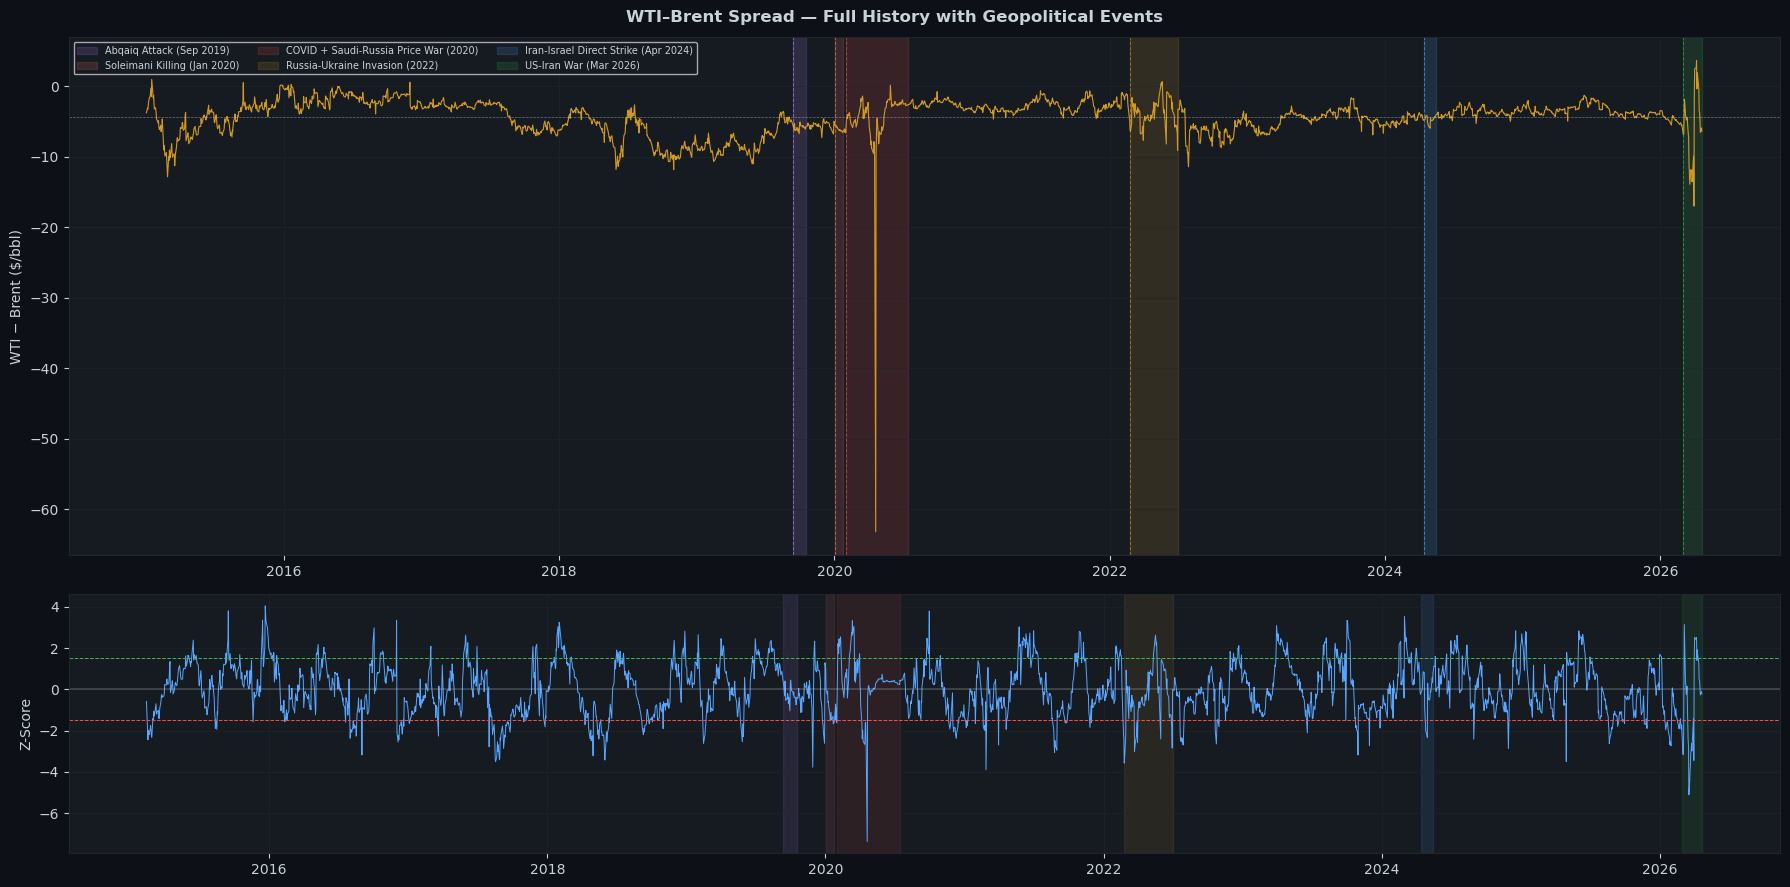

In [16]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 9), facecolor=DARK,
                                gridspec_kw={"height_ratios": [2, 1]})
fig.suptitle("WTI–Brent Spread — Full History with Geopolitical Events",
             color=TEXT, fontsize=12, fontweight="bold")

ss = signals["wti_brent"]

ax1.plot(ss.spread.index, ss.spread, color=GOLD, lw=0.8)
ax1.axhline(ss.spread.mean(), color=TEXT, ls="--", lw=0.5, alpha=0.5)
ax1.set_ylabel("WTI − Brent ($/bbl)")
ax1.grid(True, color=GRID, lw=0.4)
ax1.set_facecolor(PANEL)
for sp in ax1.spines.values():
    sp.set_color(GRID)

for name, ev in EVENTS.items():
    label = name.replace("\n", " ")
    ax1.axvspan(pd.Timestamp(ev["start"]), pd.Timestamp(ev["end"]),
                color=ev["color"], alpha=0.15, label=label)
    ax1.axvline(pd.Timestamp(ev["start"]), color=ev["color"], lw=0.7, ls="--", alpha=0.6)

ax1.legend(fontsize=7, facecolor=PANEL, labelcolor=TEXT, ncol=3)

ax2.plot(ss.zscore.index, ss.zscore, color=BLUE, lw=0.7)
ax2.axhline( ss.z_entry, color=GREEN, ls="--", lw=0.7)
ax2.axhline(-ss.z_entry, color=RED,   ls="--", lw=0.7)
ax2.axhline(0, color=TEXT, lw=0.3)
for ev in EVENTS.values():
    ax2.axvspan(pd.Timestamp(ev["start"]), pd.Timestamp(ev["end"]),
                color=ev["color"], alpha=0.10)
ax2.set_ylabel("Z-Score")
ax2.grid(True, color=GRID, lw=0.4)
ax2.set_facecolor(PANEL)
for sp in ax2.spines.values():
    sp.set_color(GRID)

plt.tight_layout()
plt.show()


## 3-2-1 Crack Spread: Full History with Event Overlays

The 3-2-1 crack spread (refinery margin) reacts differently to each event type:
- **Supply disruptions** → crude spikes → crack compresses (refiners squeezed)
- **Demand destruction** → products fall faster → crack inverts
- **Infrastructure attacks** → product supply disruption → crack widens


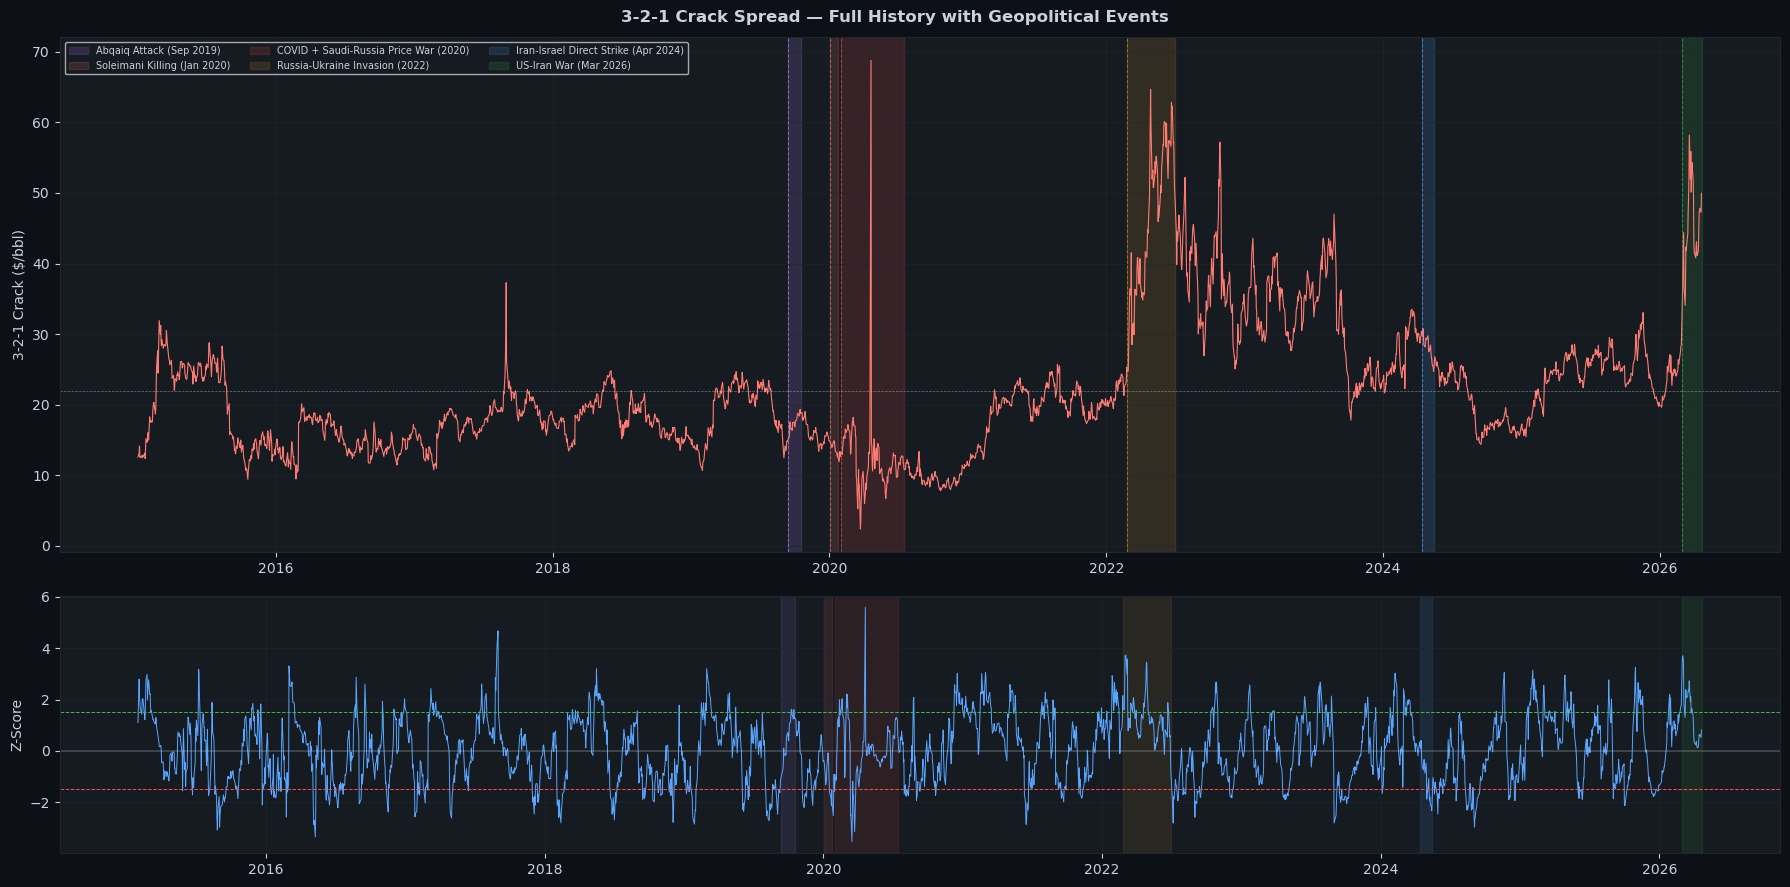

In [17]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 9), facecolor=DARK,
                                gridspec_kw={"height_ratios": [2, 1]})
fig.suptitle("3-2-1 Crack Spread — Full History with Geopolitical Events",
             color=TEXT, fontsize=12, fontweight="bold")

ss = signals["crack_321"]

ax1.plot(ss.spread.index, ss.spread, color=ORANGE, lw=0.8)
ax1.axhline(ss.spread.mean(), color=TEXT, ls="--", lw=0.5, alpha=0.5)
ax1.set_ylabel("3-2-1 Crack ($/bbl)")
ax1.grid(True, color=GRID, lw=0.4)
ax1.set_facecolor(PANEL)
for sp in ax1.spines.values():
    sp.set_color(GRID)

for name, ev in EVENTS.items():
    label = name.replace("\n", " ")
    ax1.axvspan(pd.Timestamp(ev["start"]), pd.Timestamp(ev["end"]),
                color=ev["color"], alpha=0.15, label=label)
    ax1.axvline(pd.Timestamp(ev["start"]), color=ev["color"], lw=0.7, ls="--", alpha=0.6)

ax1.legend(fontsize=7, facecolor=PANEL, labelcolor=TEXT, ncol=3)

ax2.plot(ss.zscore.index, ss.zscore, color=BLUE, lw=0.7)
ax2.axhline( ss.z_entry, color=GREEN, ls="--", lw=0.7)
ax2.axhline(-ss.z_entry, color=RED,   ls="--", lw=0.7)
ax2.axhline(0, color=TEXT, lw=0.3)
for ev in EVENTS.values():
    ax2.axvspan(pd.Timestamp(ev["start"]), pd.Timestamp(ev["end"]),
                color=ev["color"], alpha=0.10)
ax2.set_ylabel("Z-Score")
ax2.grid(True, color=GRID, lw=0.4)
ax2.set_facecolor(PANEL)
for sp in ax2.spines.values():
    sp.set_color(GRID)

plt.tight_layout()
plt.show()


## Conclusions

### Pattern by Event Type

**Short, sharp spikes (Soleimani, Abqaiq, Iran-Israel):**
- Geopolitical risk premium fades within 1–3 weeks as the market reassesses actual
  supply impact. The strategy benefits by *shorting* spreads that have overshot and
  *riding the reversion*. Win rates tend to be high in these periods.

**Prolonged supply/demand shocks (COVID, Russia-Ukraine):**
- Mean reversion assumptions break down for weeks or months. Spreads reach extreme
  z-scores and *stay there*. The ATR-based stop loss is critical here — positions that
  go wrong get cut before losses compound.
- These are the worst periods for the strategy. The COVID window showed the most
  severe drawdown in the 10-year backtest.

**Sustained geopolitical wars (Russia-Ukraine, US-Iran 2026):**
- Initial shock trades can be profitable (fading the overreaction), but new structural
  regimes emerge (e.g. European energy self-sufficiency post-Ukraine, Hormuz risk
  premium post US-Iran). Longer lookback windows (90–120d) adapt better to these regimes
  than the default 40–60d.

### Spread-Specific Takeaways
| Spread | Most Sensitive To | Behaviour |
|---|---|---|
| WTI–Brent | Middle East supply risk | Brent premium spikes on Hormuz fears; reverts as risk fades |
| 3-2-1 / 2-1-1 Crack | Supply disruptions | Compresses when crude spikes; widens on refinery/product disruption |
| HO Crack | European energy crisis | Extreme widening during Russia-Ukraine; mean reverts slowly |
| RB Crack | Demand shocks | Demand destruction (COVID) → RB falls faster than crude |
| Butterflies | Cross-grade dislocations | Good mean reversion properties across all events |

### Recommendation
Consider adding a **regime filter** that widens z-entry thresholds (e.g. to 2.0–2.5)
when VIX or realised oil volatility is elevated — this would reduce false entries during
the early stages of major dislocations and improve performance in the worst event windows.
